In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')
from FAR.utils.measure import Measure, ClusterProcessor, Binning
from FAR.utils.read import LogitToStat, RecoveryData, DataProcessor, Merge
from FAR.utils.predict import predictFeatures
from FAR.utils.utilities import rename_columns, getFARCatalog, remove_little_dogs, rename_data
from FAR.utils.plot import Plotting as pl
from src.torch_utils import load_model, predictions
from sklearn import metrics
import matplotlib.pyplot as plt
import torch
from gwpy.timeseries import TimeSeries
from itertools import product
import math
import pickle
from matplotlib.colors import LinearSegmentedColormap, Normalize
import time
from matplotlib.ticker import ScalarFormatter
import re
np.set_printoptions(precision=6, suppress=True)
#pd.options.mode.chained_assignment = None
pd.set_option('display.float_format', '{:.3f}'.format)


path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = '/git_new/computational-aspects-of-machine-learning-project-3/FAR/timeslides_1132.9y.csv'
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]
merge = Merge(path_store, path + timeslides_file)
dark_colors = ['indigo','navy', 'mediumvioletred', 'darkgreen']
colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]

In [2]:
def computeCounts(tmp, ifo, bins, ycol, p_star):
    
    TPR, yerr, mean_var, xerr = [], [], [], []
    
    for b in range(len(bins) - 1):

        
        if bins[b + 1] != bins[-1]:
            select = tmp[(tmp[ycol] >= bins[b]) & (tmp[ycol] < bins[b + 1])]
        else:
            print(b)
            select = tmp[tmp[ycol] >= bins[-1]]
        
        tp, p, _, _ = Measure.TPR(select, ifo, p_star=p_star)
        if bins[b] >= 13000: print(bins[b], tp/ p, tp, p)
        if p > 0:
            mean_var.append(np.mean(select[ycol]))
            xerr.append(3 * np.std(select[ycol]) / p)
            TPR.append(tp / p)
            #yerr.append(np.sqrt((tp/p)*(1-tp/p) / (p))) Binomial distribution
            yerr.append(np.sqrt(tp)/p)
        else:
            mean_var.append(np.nan)
            xerr.append(np.nan)
            TPR.append(np.nan)
            yerr.append(np.nan)

    return TPR, yerr, mean_var, xerr

def process_column(df, column_name, ifo):
    # Function to convert string to list of floats
    def string_to_float_list(input_string):
        if isinstance(input_string, np.ndarray):
            # Apparently some data does not need 
            # To transform to float... FIXME
            numbers_as_floats = input_string
            return numbers_as_floats
        if type(input_string) is float:
            # For injections sometimes we do not find the 
            # signal
            numbers_as_floats = [np.nan]
            return numbers_as_floats
        else:
            cleaned_string = input_string.strip('[]')
            numbers_as_strings = re.findall(r'[-+]?\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+', cleaned_string)
            numbers_as_floats = [float(number) for number in numbers_as_strings]
            return numbers_as_floats

    # Function to extract the first and second values
    def extract_first_and_second(values):
        first = values[0] if len(values) > 0 else None
        second = values[1] if len(values) > 1 else None
        return first, second

    # Apply the function to convert strings to lists of floats
    df[f'feature_{ifo}_new'] = df[column_name].apply(string_to_float_list)

    # Apply the function and expand the result into two columns
    df[[f'SNR_av_{ifo}', f'Chisq_av_{ifo}']] = df[f'feature_{ifo}_new'].apply(extract_first_and_second).apply(pd.Series)

    # Drop the intermediate column if no longer needed
    df.drop(columns=[f'feature_{ifo}_new'], inplace=True)

    return df

def plotDistandSNR(datas, var, ifos, colors, t_searches, epsilon=1e-4, FAR=0.1, new_stat=False):

    # Define variables
    bins_dist = np.arange(0, 14000, 1000)
    bins_snr = np.concatenate([np.arange(0, 9), np.arange(10, 19, 2), np.arange(20, 55, 5)])
    
    if var == 'SNR': bins, xlabel = bins_snr, 'Injected SNR'
    elif var == 'distance': bins, xlabel = bins_dist, r'Luminosity distance $D_{L}$ (Mpc)'

    var, TPRs = [], []
    for data, ifo, color, t_search in zip(datas, ifos, colors, t_searches): 

        t_bkg, bkg = merge.mergeTriggers(ifo.replace('1', ""), new_stat) # FIXME

        if len(ifo) == 4:
            ifo1, ifo2 = ifo[:2], ifo[2:]
            
            if new_stat:
                # bkg = process_column(bkg, 'feature_'+ifo1, ifo1)
                # bkg = process_column(bkg, 'feature_'+ifo2, ifo2)

                stat1 = bkg[f'Pinj_{ifo1}'] / (bkg[f'Chisq_max_{ifo1}'] / bkg[f'SNR_max_{ifo1}']**2)
                stat2 = bkg[f'Pinj_{ifo2}'] / (bkg[f'Chisq_max_{ifo2}'] / bkg[f'SNR_max_{ifo2}']**2)
                bkg['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
                bkg['rank_stat_'+ifo1+ifo2] = bkg['barPinj']

                # data = process_column(data, 'feature_'+ifo1, ifo1)
                # data = process_column(data, 'feature_'+ifo2, ifo2)
                
                stat1 = data[f'Pinj_{ifo1}'] / (data[f'Chisq_max_{ifo1}'] / data[f'SNR_max_{ifo1}']**2)
                stat2 = data[f'Pinj_{ifo2}'] / (data[f'Chisq_max_{ifo2}'] / data[f'SNR_max_{ifo2}']**2)
                data['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
                data['rank_stat_'+ifo1+ifo2] = data['barPinj'] 
            else:
                stat1 = bkg[f'Pinj_{ifo1}']
                stat2 = bkg[f'Pinj_{ifo2}']
                bkg['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
                bkg = Measure.prob2stat(bkg, ifo1+ifo2, col='barPinj')

            data['injSNR' + ifo] = np.sqrt(data['injSNR'+ifo[:2]]**2 + data['injSNR'+ ifo[2:]]**2)
 
        x, y_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
        print(ifo, p_star)
        if xlabel == 'Injected SNR': ycol = 'injSNR'+ifo
        else: ycol = 'Distance'

        TPR, yerr, mean_var, xerr = computeCounts(data, ifo, bins, ycol, p_star)

        var.append(mean_var)
        TPRs.append(TPR)
        plt.plot(mean_var, np.asarray(TPR) + epsilon, label=ifo, c=color, alpha=0.8)
        plt.errorbar(mean_var, TPR, yerr=yerr, xerr=xerr,
                     fmt='o', capsize=2, color=color,
                     markerfacecolor=color, markersize=1, zorder=1)
        
        if xlabel == 'Injected SNR':
            plt.xticks([1, 5] + np.arange(10, 80, 10).tolist())
            plt.xlim(1)
        #plt.yscale('log')
        #plt.yticks([epsilon, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40],
        #           [0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40])
        #plt.ylim(epsilon, 0.4)
        plt.legend()
        plt.xlabel(xlabel), plt.ylabel('TPR')
        
        
    plt.legend(), plt.ylim((0, 1.05)), plt.grid(True)
    plt.show()
    return var, TPRs

def plot_inverse_cumulative_histogram(data, bins=10):
    # Compute the histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Compute the cumulative sum of the counts in reverse order
    inverse_cumulative_counts = np.cumsum(counts[::-1])[::-1]

    return bin_edges, inverse_cumulative_counts

### Injections test

In [3]:
# path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
# inj_hl = predictFeatures(path_inj + 'inj_coinc2_hl.csv', ['h1', 'l1'], 'inj')
# inj_hv = predictFeatures(path_inj + 'inj_coinc2_hv.csv', ['h1', 'v1'], 'inj')
# inj_lv = predictFeatures(path_inj + 'inj_coinc2_lv.csv', ['l1', 'v1'], 'inj')
# inj_hlv = predictFeatures(path_inj + 'inj_coinc3_hlv.csv', ['h1', 'l1', 'v1'], 'inj')

# inj_hl = rename_data('H1L1', inj_hl)
# inj_hv = rename_data('H1V1', inj_hv)
# inj_lv = rename_data('L1V1', inj_lv)
# inj_hlv = rename_data('H1L1V1', inj_hlv)

# inj_hl.to_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
# inj_hv.to_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
# inj_lv.to_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
# inj_hlv.to_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

In [4]:
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
inj_hl = pd.read_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
inj_hv = pd.read_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
inj_lv = pd.read_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
inj_hlv = pd.read_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

In [5]:
with open(path_inj + f'clusters_h1.pkl', 'rb') as f:
    inj_c_h1 = pickle.load(f)
with open(path_inj + f'clusters_l1.pkl', 'rb') as f:
    inj_c_l1 = pickle.load(f)
with open(path_inj + f'clusters_v1.pkl', 'rb') as f:
    inj_c_v1 = pickle.load(f)

### Proper time

#### Some plottting

H1L1 9479.725420492403
H1V1 9382.44537166927
L1V1 9133.73150009325


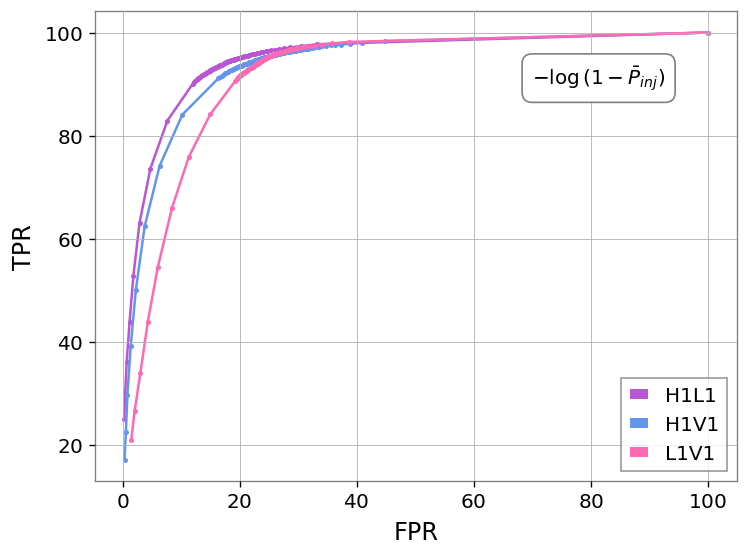

In [22]:
dt = np.concatenate([np.zeros(1), np.arange(0.01, 0.9, 0.01),
                     np.asarray([0.9, 0.99, 0.999, 0.9999,
                                 0.99999, 0.999999,0.9999999,
                                 0.99999999, 0.999999999])])
fig, axs = plt.subplots(1, 1, dpi=120)
for c, ifo, t_search,  inj in zip(colors, ifos, t_searches, [inj_hl, inj_hv, inj_lv]):
    
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    
    pos, neg = inj.copy(), bkg.copy()
    for d in dt:
        p_star = - np.log(1 - d + 1e-20)
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, marker='o', c=c, markersize=2,
             label=ifo)
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR'), axs.legend()
plt.text(70, 90, r'$- \log{(1-\bar{P}_{inj})}$', bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.5'))
plt.tight_layout()

H1L1 9742.86215629233
H1V1 9707.294157094155
L1V1 9710.92353470154


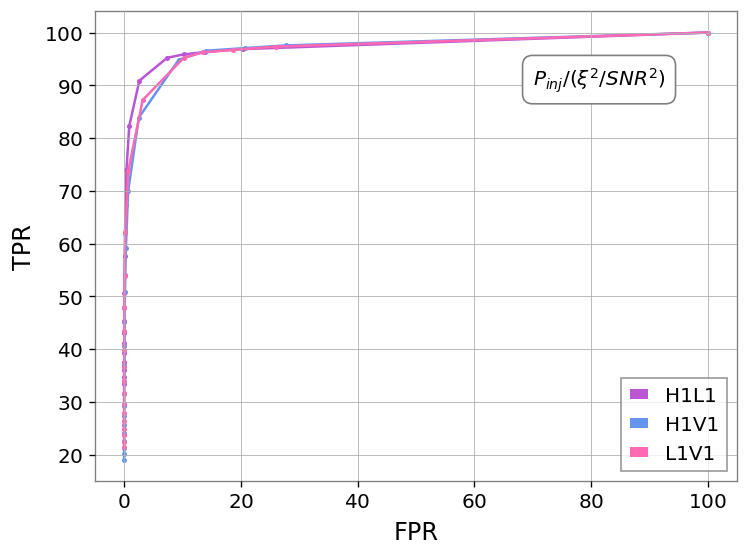

In [23]:
dt = np.concatenate([np.arange(0, 20, 5), np.arange(20, 190, 10),
                     np.arange(190, 200, 10)])
new_stat = True
fig, axs = plt.subplots(1, 1, dpi=120)
for c, ifo, t_search,  inj in zip(colors, ifos, t_searches, [inj_hl, inj_hv, inj_lv]):

    ifo1, ifo2 = ifo[:2], ifo[2:]
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, new_stat=new_stat) # FIXME
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    
    if new_stat:
        stat1 = pos[f'Pinj_{ifo1}'] / (pos[f'Chisq_max_{ifo1}'] / pos[f'SNR_max_{ifo1}']**2)
        stat2 = pos[f'Pinj_{ifo2}'] / (pos[f'Chisq_max_{ifo2}'] / pos[f'SNR_max_{ifo2}']**2)
        pos['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
        pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

    
    for d in dt:
        p_star = d
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, marker='o', c=c, markersize=2,
             label=ifo)
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR'), axs.legend()
plt.text(70, 90, r'$P_{inj}/(\xi^2/SNR^2)$', bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.5'))
plt.tight_layout()

H1L1 6.15
19
H1V1 6.62
19
L1V1 10.57
19


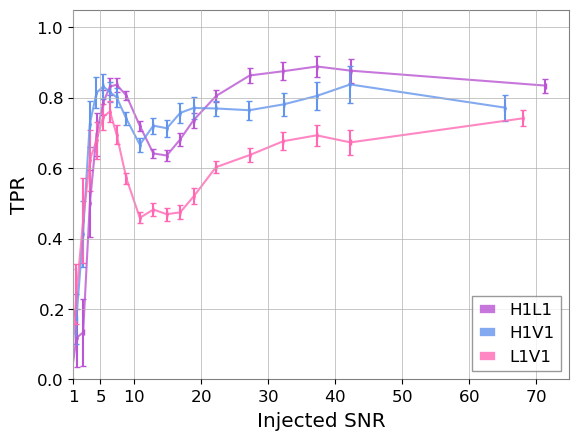

H1L1 6.15
12
H1V1 6.62
12
L1V1 10.57
12


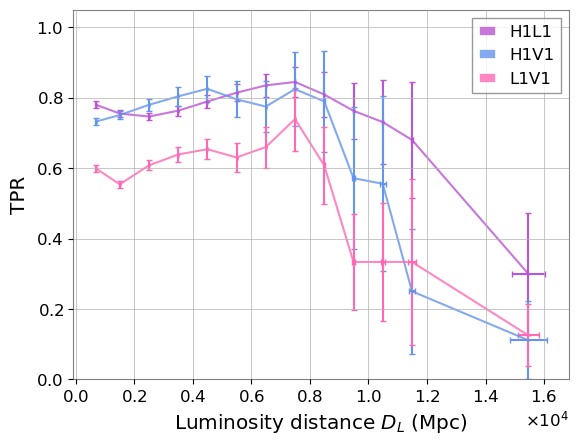

In [4]:
snrs, tpr_snrs = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'SNR', 
                                ifos[:-1], colors[:-1], t_searches[:-1])
dists, tpr_dists = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'distance',
                                  ifos[:-1], colors[:-1], t_searches[:-1])

H1L1 23.3
19
H1V1 22.990000000000002
19
L1V1 24.3
19


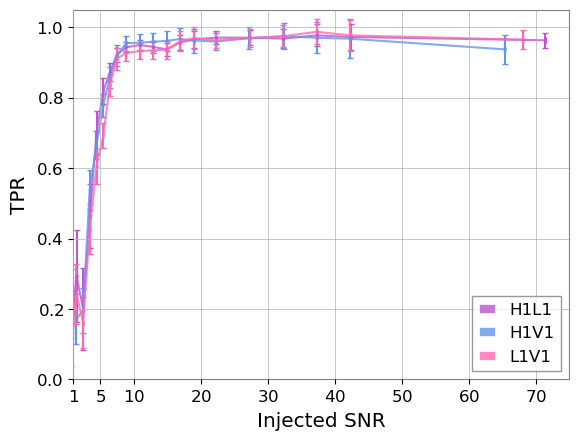

H1L1 23.3
12
H1V1 22.990000000000002
12
L1V1 24.3
12


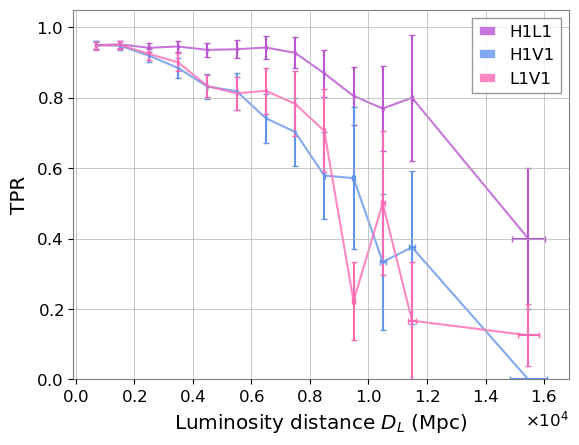

In [24]:
snrs, tpr_snrs = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'SNR', 
                                ifos[:-1], colors[:-1], t_searches[:-1], new_stat=True)
dists, tpr_dists = plotDistandSNR([inj_hl, inj_hv, inj_lv], 'distance',
                                  ifos[:-1], colors[:-1], t_searches[:-1], new_stat=True)

H1L1
H1V1
L1V1


Text(0, 0.5, 'FAR (yr$^{-1})$')

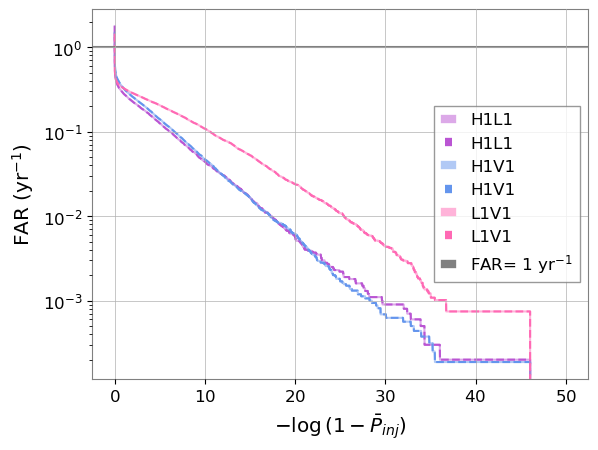

In [7]:
merge = Merge(path_store, path + timeslides_file)

ifo, t_search, FAR = 'H1L1', 0.5, 0.01
for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):
    print(ifo)
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    x, y_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
    plt.plot(x, y_obs, label=ifo, c=color, alpha=0.5)

    bkg_ = remove_little_dogs(catalog, bkg, ifo)
    x, y_obs_, p_star, ylabel = Measure.getFARandThreshold(bkg_, ifo, t_bkg, t_search, FAR=FAR)
    plt.plot(x, y_obs_, label=ifo, linestyle='--', c=color)
plt.axhline(1, label='FAR= 1 yr$^{-1}$', c='grey')
plt.legend()
plt.yscale('log')
plt.xlabel(r'$- \log{(1-\bar{P}_{inj})}$')
plt.ylabel('FAR (yr$^{-1})$')


H1L1
17763 17755 1000.0
H1V1
23701 23694 1001.0
L1V1
21204 21196 1000.0


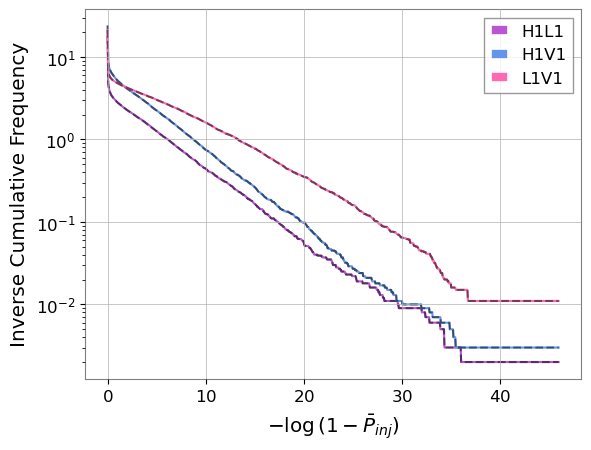

In [21]:
for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):
    print(ifo)
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME

    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)
    print(len(bkg), len(bkg_), t_bkg)

    b1, i1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
    b2, i2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
    
    # Plot the inverse cumulative histogram
    plt.plot(b1[:-1], i1/t_bkg, color=color, label=ifo)
    plt.plot(b2[:-1], i2/t_bkg, alpha=0.5, linestyle='--', color='black')
    plt.xlabel(r'$- \log{(1-\bar{P}_{inj})}$')
    plt.ylabel('Inverse Cumulative Frequency')
    
    plt.yscale('log')
    plt.legend()

H1L1 17763 17755 1000.0
H1V1 23701 23694 1001.0
L1V1 21204 21196 1000.0


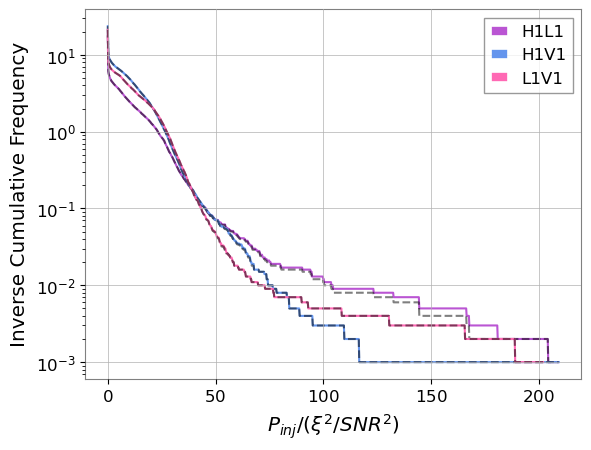

In [30]:
for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):

    t_bkg, bkg = merge.mergeTriggers(ifo, new_stat=True) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)
    print(ifo, len(bkg), len(bkg_), t_bkg)

    b1, i1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
    b2, i2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
    
    # Plot the inverse cumulative histogram
    plt.plot(b1[:-1], i1/t_bkg, color=color, label=ifo)
    plt.plot(b2[:-1], i2/t_bkg, alpha=0.5, linestyle='--', color='black')
    plt.xlabel(r'$P_{inj}/(\xi^2/SNR^2)$')
    plt.ylabel('Inverse Cumulative Frequency')
    plt.yscale('log')
    plt.legend()

In [31]:
ifo = 'H1L1'
ifo1, ifo2 = ifo[:2], ifo[2:]
t_bkg, bkg = merge.mergeTriggers(ifo, new_stat=True)
bkg = bkg.sort_values(by='rank_stat_'+ifo, ascending=False)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo1.lower()}_reduced.pkl', 'rb') as f:
    cluster1 = pickle.load(f)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo2.lower()}_reduced.pkl', 'rb') as f:
    cluster2 = pickle.load(f)

In [32]:
bkg[['Pinj_H1', 'Pinj_L1', 
     'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1',
     'rank_stat_'+ifo1+ifo2]].head(5)

,Pinj_H1,Pinj_L1,SNR_max_H1,SNR_max_L1,Chisq_max_H1,Chisq_max_L1,rank_stat_H1L1
8371,0.987,0.569,15.933,9.945,1.713,0.153,209.252
13352,1.000,0.999,7.707,18.059,0.286,1.621,204.331
3586,1.000,1.000,10.550,13.093,0.770,0.708,180.998
8426,0.999,1.000,78.963,45.739,18.125,18.868,167.650
2856,0.997,0.918,13.193,27.353,0.879,4.776,166.427


In [79]:
display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])

Pinj_H1         0.997
Pinj_L1         0.918
SNR_max_H1     13.193
SNR_max_L1     27.353
Chisq_max_H1    0.879
Chisq_max_L1    4.776
Name: 2856, dtype: object

1242722046.0895252 1242722046.0724351
1242722046.0895252 1242719583.0724351


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


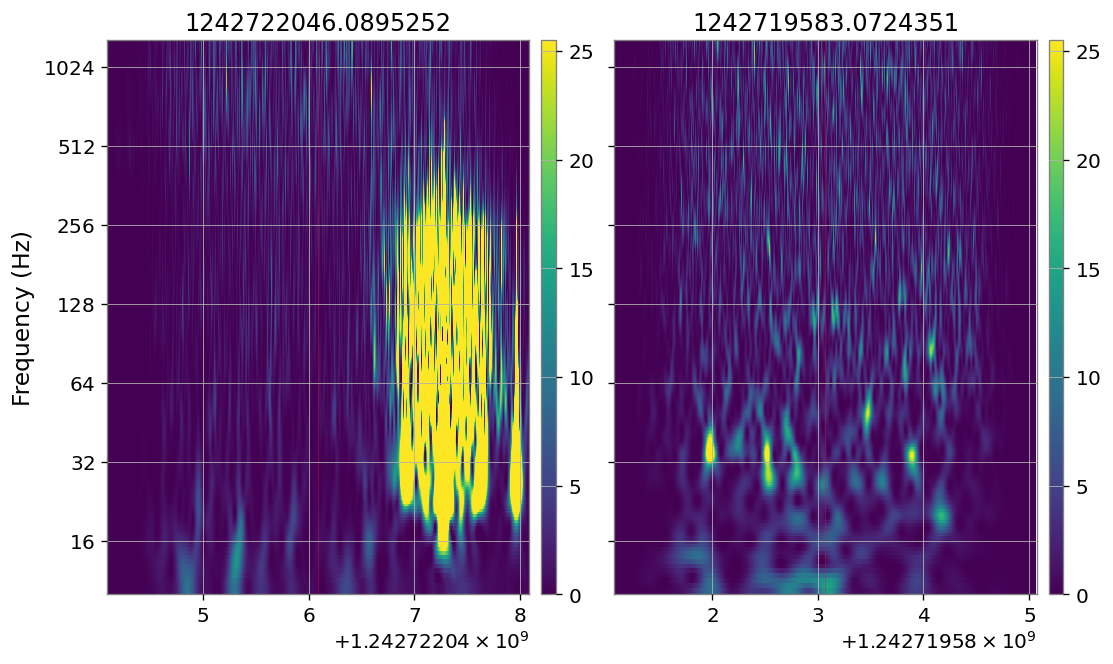

Pinj_H1         0.987
Pinj_L1         0.569
SNR_max_H1     15.933
SNR_max_L1      9.945
Chisq_max_H1    1.713
Chisq_max_L1    0.153
Name: 8371, dtype: object

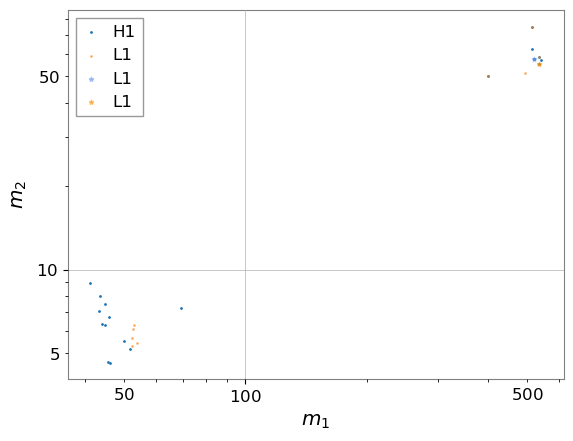

1261550983.2037835 1261550983.2047596
1261550983.2037835 1261546990.2047596


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


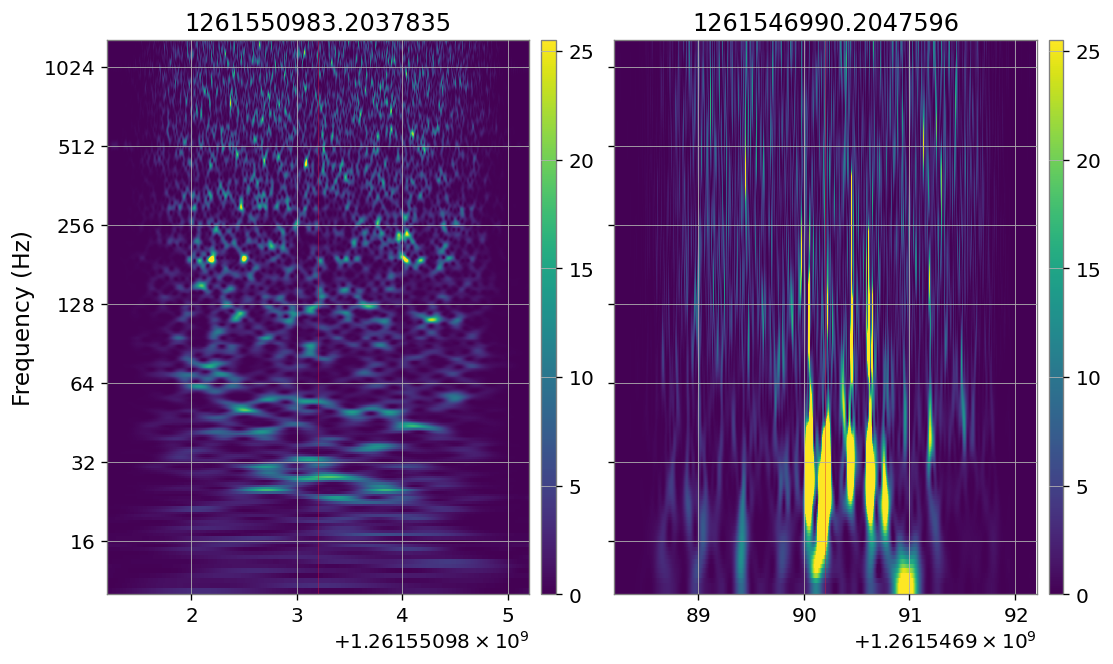

Pinj_H1         1.000
Pinj_L1         0.999
SNR_max_H1      7.707
SNR_max_L1     18.059
Chisq_max_H1    0.286
Chisq_max_L1    1.621
Name: 13352, dtype: object

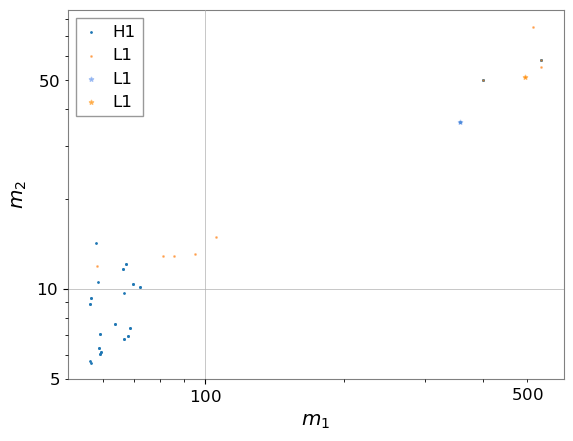

1266619183.3654037 1266619183.402307
1266619183.3654037 1266618172.402307


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


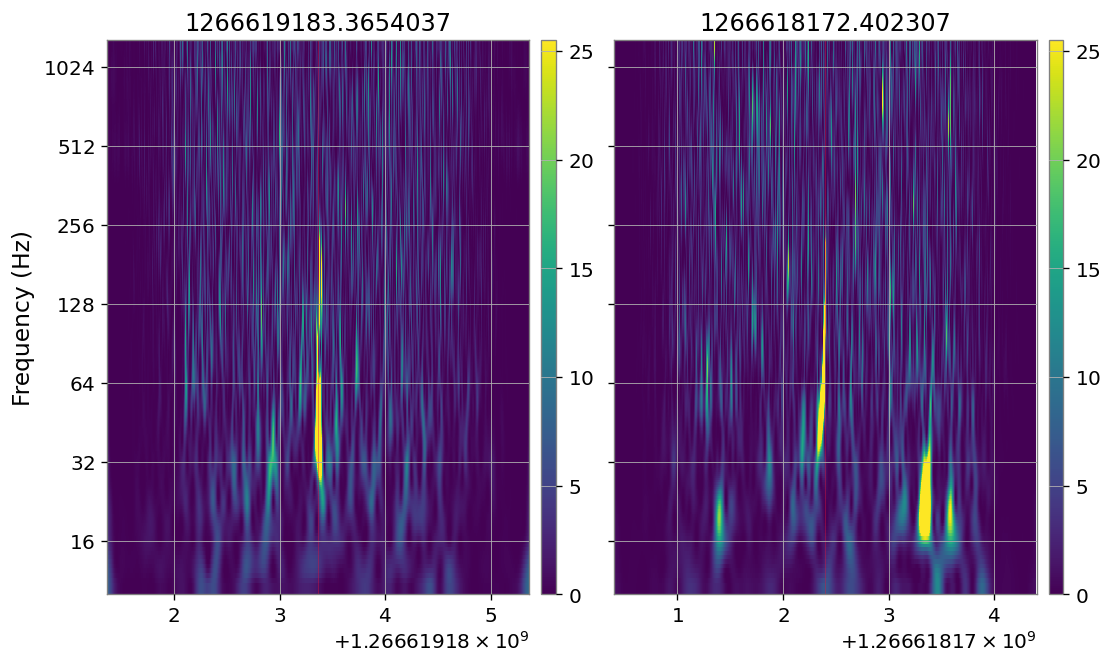

Pinj_H1         1.000
Pinj_L1         1.000
SNR_max_H1     10.550
SNR_max_L1     13.093
Chisq_max_H1    0.770
Chisq_max_L1    0.708
Name: 3586, dtype: object

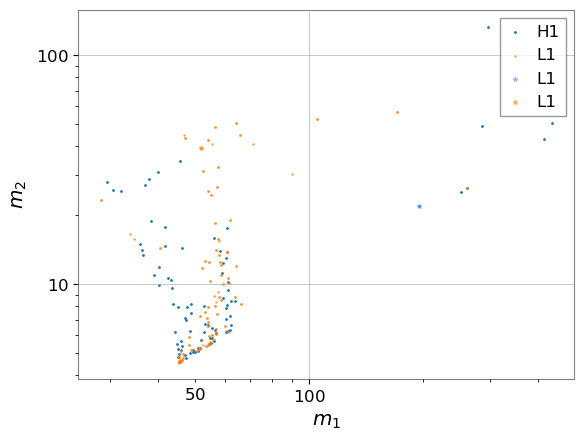

1245747256.2780025 1245747256.2775135
1245747256.2780025 1245744778.2775135


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


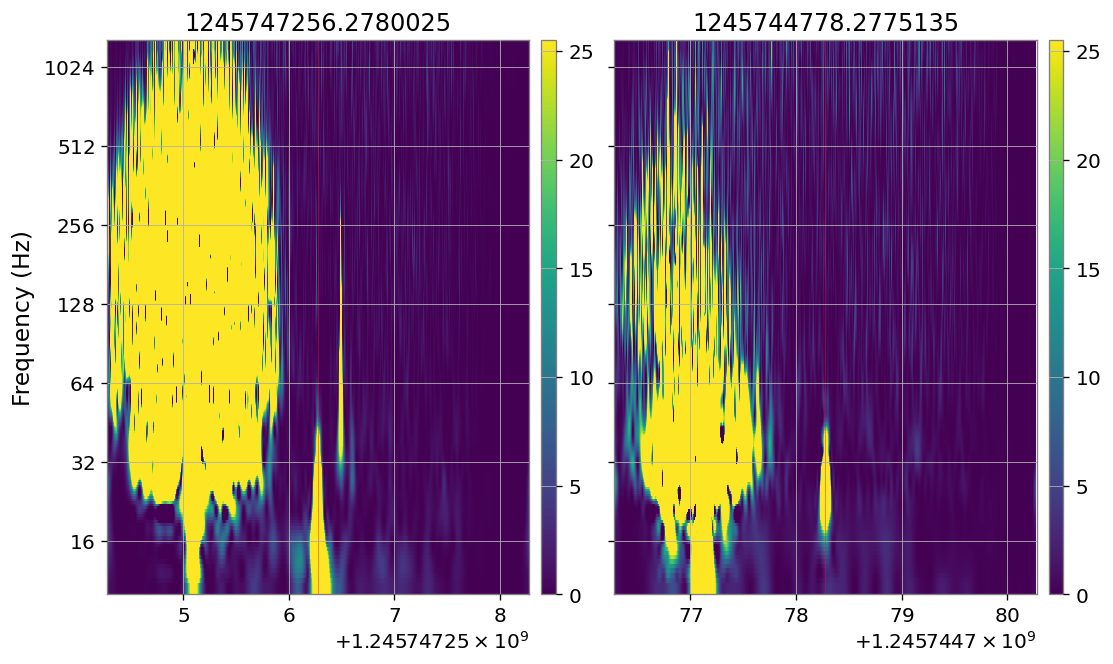

Pinj_H1         0.999
Pinj_L1         1.000
SNR_max_H1     78.963
SNR_max_L1     45.739
Chisq_max_H1   18.125
Chisq_max_L1   18.868
Name: 8426, dtype: object

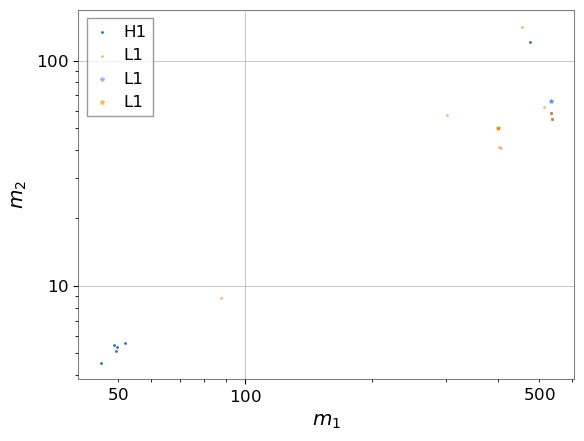

1257444292.8585696 1257444292.8400145
1257444292.8585696 1257443494.8400145


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


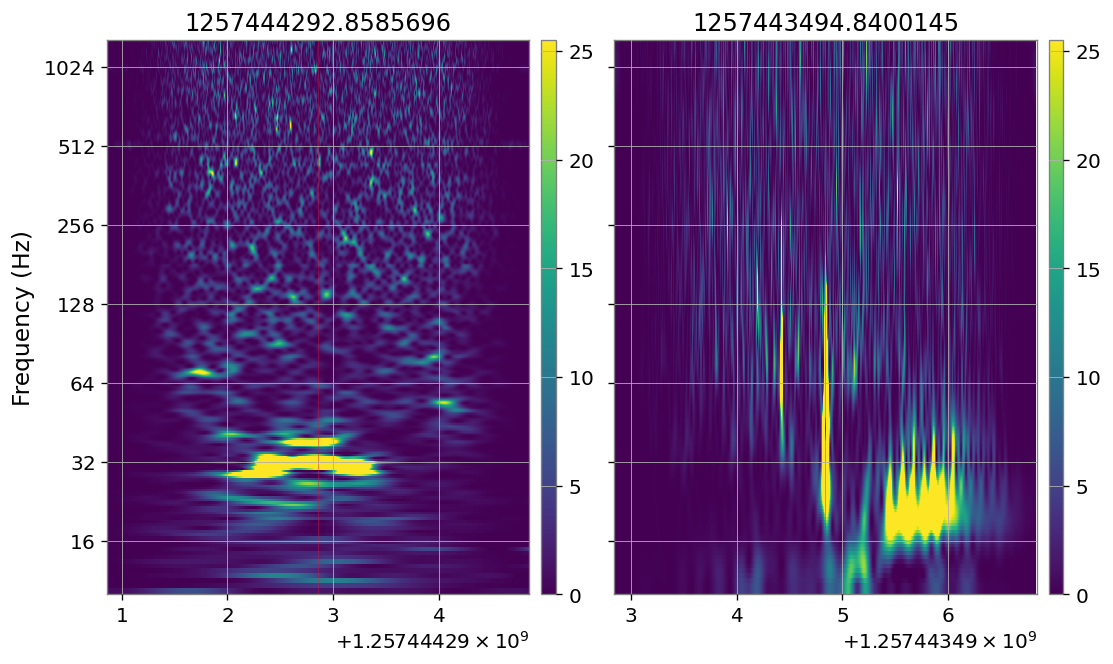

Pinj_H1         0.997
Pinj_L1         0.918
SNR_max_H1     13.193
SNR_max_L1     27.353
Chisq_max_H1    0.879
Chisq_max_L1    4.776
Name: 2856, dtype: object

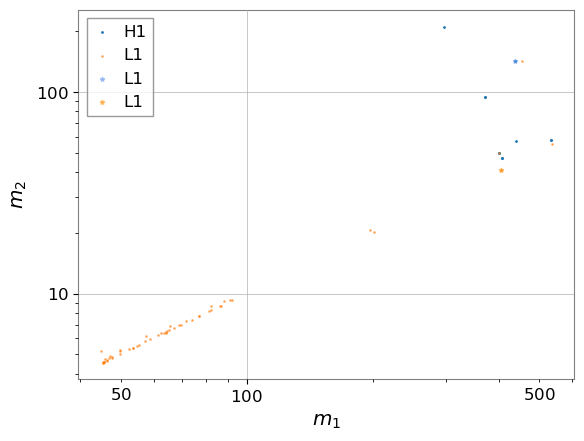

In [81]:

for i in range(5):
    print(bkg.iloc[i]['Cluster time_'+ifo1], bkg.iloc[i]['Cluster time_'+ifo2])
    print(bkg.iloc[i]['Cluster time old_'+ifo1], bkg.iloc[i]['Cluster time old_'+ifo2])
    pl.plotSpect2coinc(ifo1, ifo2, bkg.iloc[i]['Cluster time old_'+ifo1],
                    bkg.iloc[i]['Cluster time old_'+ifo2])
    display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])
    plt.scatter(cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_1'],
                cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_2'], s=1, label=ifo1)
    plt.scatter(cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_1'], 
                cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_2'], s=1, alpha=0.5, label=ifo2)
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo1], bkg.iloc[i]['Mass_2_max_'+ifo1],
                s=10, marker='*', alpha=0.5, label=ifo2, c='cornflowerblue')
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo2], bkg.iloc[i]['Mass_2_max_'+ifo2],
                s=10, marker='*', alpha=0.5, label=ifo2, c='darkorange')

    plt.xlabel('$m_1$'), plt.ylabel('$m_2$')
    plt.xscale('log'), plt.yscale('log')
    plt.legend()
    plt.show()

1238166114.4306576 1238166114.4367027 -0.006045103073120117


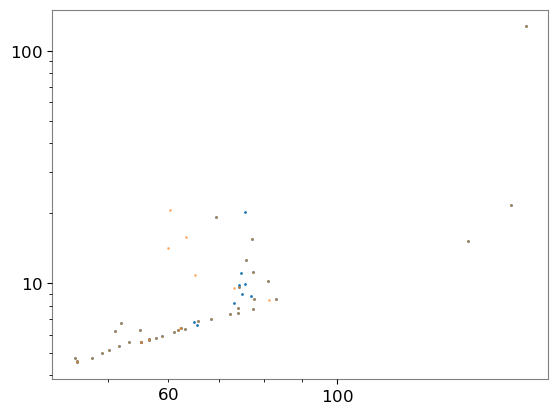

1238166274.0581386 1238166274.0541856 0.003952980041503906


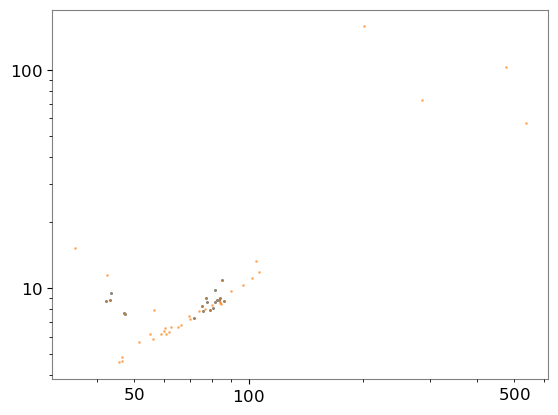

1238166498.2288494 1238166498.223775 0.005074501037597656


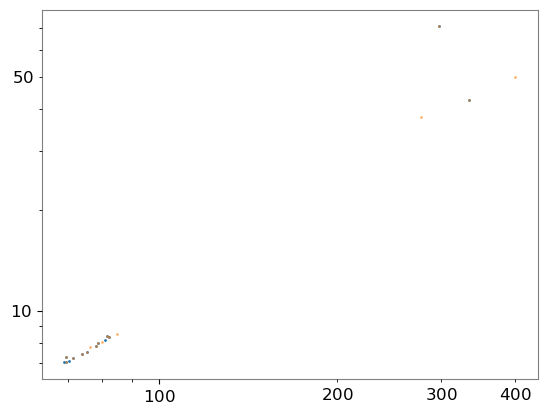

1238166690.3785937 1238166690.388106 -0.00951242446899414


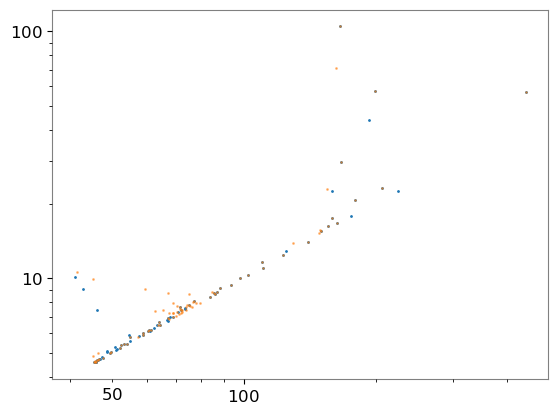

1238166818.9237006 1238166818.9176953 0.006005287170410156


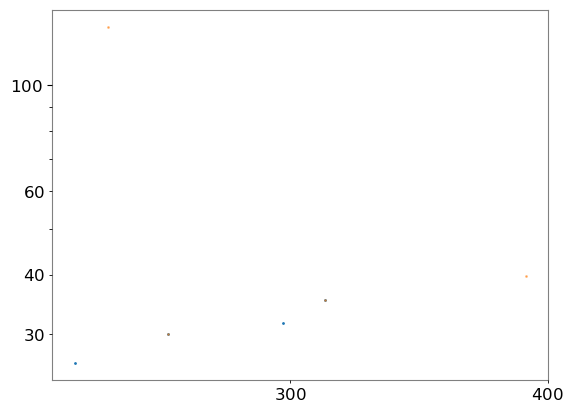

1238166850.4056952 1238166850.3964808 0.009214401245117188


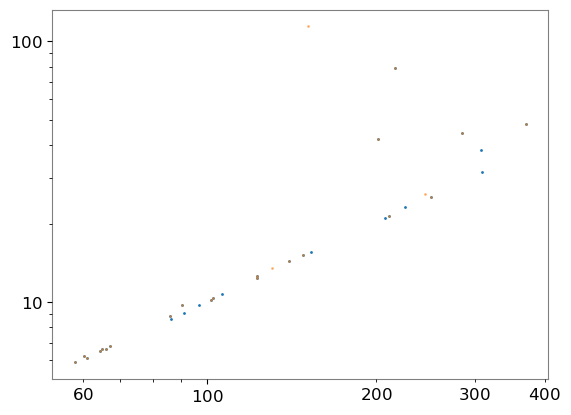

1238166946.5224535 1238166946.5299814 -0.007527828216552734


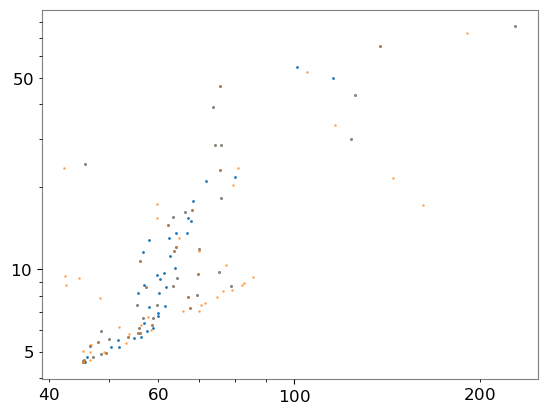

1238167106.2882884 1238167106.2853713 0.002917051315307617


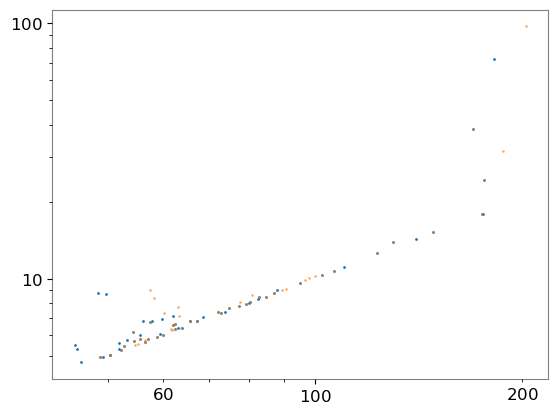

1238167298.2468696 1238167298.2461777 0.0006918907165527344


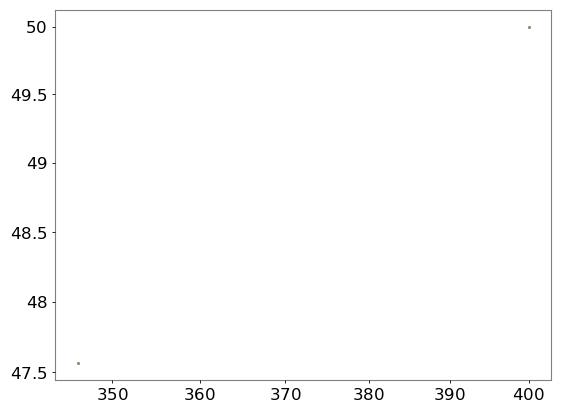

1238167362.108396 1238167362.1162543 -0.0078582763671875


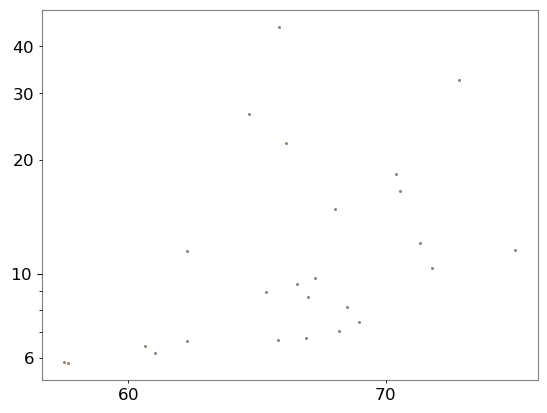

In [74]:
for i in range(10):
    tmp1 = inj_c_h1[i]
    tmp2 = inj_c_l1[i]
    # display(tmp1)
    # display(tmp2)
    print(np.unique(tmp1['Cluster time'])[0], np.unique(tmp2['Cluster time'])[0], np.unique(tmp1['Cluster time'])[0] - np.unique(tmp2['Cluster time'])[0])
    plt.scatter(tmp1['Mass_1'], tmp1['Mass_2'], s=1)
    plt.scatter(tmp2['Mass_1'], tmp2['Mass_2'], alpha=0.5, s=1)
    plt.xscale('log'), plt.yscale('log')
    plt.grid(False)
    plt.show()

### Zero lag test

In [15]:
%%time
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

u_h1 = predictFeatures(path_inj + 'unknown_h1_reduced.csv', ['h1'], 'zero_lag')
u_l1 = predictFeatures(path_inj + 'unknown_l1_reduced.csv', ['l1'], 'zero_lag')
u_v1 = predictFeatures(path_inj + 'unknown_v1_reduced.csv', ['v1'], 'zero_lag')

98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


99.05Acc_V1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2382epochs_10batches.pth
CPU times: user 1min 31s, sys: 1min 49s, total: 3min 21s
Wall time: 32.2 s


/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


In [18]:
path_store_pred = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
u_h1.rename(columns=lambda col: rename_columns(col, '_h1', ''), inplace=True)
u_l1.rename(columns=lambda col: rename_columns(col, '_l1', ''), inplace=True)
u_v1.rename(columns=lambda col: rename_columns(col, '_v1', ''), inplace=True)

u_h1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_H1.csv')
u_l1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_L1.csv')
u_v1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_V1.csv')

### Time slides test

In [2]:
path_store = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

start_time = time.time()
u_h1, uc_h1 = dp.LoadZeroLag('h1', reset=True)
u_l1, uc_l1 = dp.LoadZeroLag('l1', reset=True)
u_v1, uc_v1 = dp.LoadZeroLag('v1', reset=True)
end_time = time.time()

In [75]:
def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
        """
        Find coincident triggers between three data sets within a time window.

        Parameters:
        x (int): Index of the trigger in data_x.
        data_x (pd.DataFrame): DataFrame containing the first set of data.
        data_y (pd.DataFrame): DataFrame containing the second set of data.
        data_z (pd.DataFrame): DataFrame containing the third set of data.
        cluster_x (dict): Dictionary containing clusters for data_x.
        cluster_y (dict): Dictionary containing clusters for data_y.
        cluster_z (dict): Dictionary containing clusters for data_z.
        shift1 (float): Time shift for the first cluster.
        shift2 (float): Time shift for the second cluster.
        shift3 (float): Time shift for the third cluster.
        window (float): Time window for finding coincident triggers.

        Returns:
        tuple: Index x, index y, index z, and delta_t values if conditions are met; otherwise, returns None values.
        """
       
        # Directly access the value instead of using iloc
        cluster_time_x = data_x.at[x, 'Cluster time']

        # Vectorized condition check
        mask = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
        tmp_y = data_y[mask]

        mask = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
        tmp_z = data_z[mask]

        if (tmp_y.empty) or (tmp_z.empty):
            return x, None, None, None, None, None

        for i, j in product(range(len(tmp_y)), range(len(tmp_z))):
            y = tmp_y.index[i]
            z = tmp_z.index[j]
            #tx, ty, tz = cluster_time_x, tmp_y['Cluster time'].iloc[i], tmp_z['Cluster time'].iloc[j]
            #print(tx, ty, tx)
            cluster1, cluster2, cluster3 = cluster_x[x], cluster_y[y], cluster_z[z]
    
            # Check the length conditions
            if len(cluster1) < 10 or len(cluster2) < 10 or len(cluster3) < 10:
                return x, None, None, None, None, None

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
            if len(tmp) > 0:
                print(i, delta_t1, delta_t2, delta_t3)
            if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                # print(delta_t1, delta_t2, delta_t3)
                return x, y, z, delta_t1, delta_t2, delta_t3
    
        return x, None, None, None, None, None

def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
    cluster_time_x = data_x.at[x, 'Cluster time']
    
    if data_x.at[x, 'Num triggers'] < 10:
        return x, None, None, None, None, None

    mask_y = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
    tmp_y = data_y[mask_y]

    mask_z = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
    tmp_z = data_z[mask_z]

    if tmp_y.empty or tmp_z.empty:
        return x, None, None, None, None, None
    
    tmp_y.reset_index(inplace=True)
    tmp_z.reset_index(inplace=True)

    results = []
    cluster1 = cluster_x[x]
    for _, row_y in tmp_y.iterrows():
        for _, row_z in tmp_z.iterrows():
            y = row_y['index']
            z = row_z['index']
            ty = row_y['Cluster time']
            tz = row_z['Cluster time']
            cluster2 = cluster_y[y]
            cluster3 = cluster_z[z]

            if len(cluster2) < 10 or len(cluster3) < 10:
                continue
            print(i, len(cluster1), len(cluster2), len(cluster3))

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            if len(tmp) > 0:
                delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
                if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                    results.append((x, y, z, delta_t1, delta_t2, delta_t3))
    
    if results:
        return results[0]
    else:
        return x, None, None, None, None, None


def mergeClusters(cluster1, cluster2, suffixes, label, shift1=0, shift2=0):
        tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
                       cluster2.drop_duplicates(subset=['Template ID']),
                       on=['Template ID'], how='inner', suffixes=suffixes)
        # if len(tmp) > 0:
        #     print('cluster', t1, t2, suffixes)
        #     print('trigger', shift1, shift2, (tmp['Trigger time' + suffixes[0]].values[0]+ shift1) - (tmp['Trigger time' + suffixes[1]].values[0]+ shift2))
        tmp[label] = np.abs((tmp['Trigger time' + suffixes[0]] + shift1)  - (tmp['Trigger time' + suffixes[1]] + shift2))
        #if tmp[label].mean() < 0.35:
        #    print(tmp[label].mean(), suffixes)
        return tmp

# def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
#         tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
#                        cluster2.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['_h1', '_l1'])
#         if len(tmp) > 0: print('hl', len(tmp))
#         # This is a hack for '_v1' suffixes
#         cluster3 = cluster3.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3.columns})
#         tmp = pd.merge(tmp.drop_duplicates(subset=['Template ID']),
#                        cluster3.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['', '_v1'])
    
#         # We shift the clusters in time
#         tmp['Trigger time_l1'] = tmp['Trigger time_l1'] + shift2
#         tmp['Trigger time_v1'] = tmp['Trigger time_v1'] + shift3

#         # And calculate delta time
#         tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
#         tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
#         tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])
#         # if len(tmp) > 0:
#         #     print(shift2, shift3)
#         #     print(tmp[['Trigger time_h1', 'Trigger time_l1', 'Trigger time_v1']])
#         #     print(tmp[['Delta t_hl', 'Delta t_hv', 'Delta t_lv']])
#         #     print(' ')
#         return tmp

def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
    # Drop duplicates before merging
    cluster1_unique = cluster1.drop_duplicates(subset=['Template ID'])
    cluster2_unique = cluster2.drop_duplicates(subset=['Template ID'])
    cluster3_unique = cluster3.drop_duplicates(subset=['Template ID'])
    # Merge cluster1 and cluster2
    tmp = pd.merge(cluster1_unique, cluster2_unique, on='Template ID', how='inner', suffixes=['_h1', '_l1'])
    print(cluster1_unique['Template ID'].values,cluster2_unique['Template ID'].values)
    print(np.intersect1d(cluster1_unique['Template ID'].values, cluster2_unique['Template ID'].values))
    if tmp.empty:
        return tmp

    # Rename columns in cluster3
    cluster3_unique = cluster3_unique.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3_unique.columns})

    # Merge with cluster3
    tmp = pd.merge(tmp, cluster3_unique, on='Template ID', how='inner')

    if tmp.empty:
        return tmp

    # Shift the clusters in time
    tmp['Trigger time_l1'] += shift2
    tmp['Trigger time_v1'] += shift3

    # Calculate delta time
    tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
    tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
    tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])

    return tmp


In [47]:
sl, sv = 0, 0
u_l1_ = dp.shiftedDataSet(u_l1, window=6)
u_v1_ = dp.shiftedDataSet(u_v1, window=12)
cp = ClusterProcessor()

In [76]:
i = 1
start = time.time()
h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                  u_v1, uc_h1,
                                                  uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
print(h4, l4, v4, t13, t23, t33)
end = time.time()
print(end - start)

1 14 16 14
[7505917. 3609158.  343444. 2512627. 5217451. 4918263.  873807. 1537736.
 1487808. 2830186.  393385. 1479407. 2205522. 1081809.] [ 150082. 6055046. 4233915. 6467480. 9804792. 9881418. 9932571. 7320522.
 4528170. 3516027.   93965.  578728. 7854497. 4306052. 7578066. 3508604.]
[]
1 None None None None None
0.008860588073730469


In [55]:
H4, L4, V4, T13, T23, T33 = [], [], [], [], [], []
for i in range(len(u_h1)):
    #if i % 1000 == 0: print(i)
    print(i)
    start = time.time()
    h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                      u_v1, uc_h1,
                                                      uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
    end = time.time()
    #print(end - start)
    H4.append(h4); L4.append(l4); T13.append(t13)

0
1
1 14 16 14
2
3
4
5
6
7
8
9
10
11
11 19 25 23
12
13
14
14 11 15 11
14 11 15 15
15
16
17
18
19
20
21
21 10 18 20
21 10 19 20
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
46 17 18 15
47
47 10 16 15
48
49
50
50 15 12 15
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
94 16 16 16
95
96
96 11 11 11
97
97 11 11 11
98
99
99 11 22 22
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
133 26 25 41
134
135
136
136 32 21 13
137
138
139
140
141
141 16 19 14
142
143
144
145
145 14 29 26
146
147
148
149
150
151
151 20 10 17
152
153
154
154 10 10 10
155
156
157
157 17 41 49
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
180 12 12 12
181
182
183
183 17 18 18
184
185
186
187
188
189
190
191
192
192 21 35 17
193
193 19 26 39
194
195
196
197
198
199
200
201
202


KeyboardInterrupt: 

### Zero lag coincidence

In [37]:
ifo = 'H1L1'
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

for ifo in ifos[:-1]:
    t_bkg, bkg = merge.mergeTriggers(ifo) 
    
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    tmp = tmp.sort_values(by='rank_stat_'+ifo, ascending=False)
    print(len(bkg), len(tmp))

17763 34090
23701 46791
21204 47214


In [95]:
!ls /data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/ -l -t | head -10

total 1175264
-rw-r--r--. 1 lopezm gravwav 16230553 Jun 26 10:13 triggersHLV_run_eq_match1_zero_background.csv
-rw-r--r--. 1 lopezm gravwav 40966707 Jun 26 10:13 triggersLV_run_eq_match1_zero_background.csv
-rw-r--r--. 1 lopezm gravwav 40638499 Jun 26 10:13 triggersHV_run_eq_match1_zero_background.csv
-rw-r--r--. 1 lopezm gravwav 30289091 Jun 26 10:13 triggersHL_run_eq_match1_zero_background.csv
-rw-r--r--. 1 lopezm gravwav     1050 Jun 20 03:09 triggersHLV_run_eq_match2081.csv
-rw-r--r--. 1 lopezm gravwav     7861 Jun 20 03:09 triggersLV_run_eq_match2081.csv
-rw-r--r--. 1 lopezm gravwav    15953 Jun 20 03:09 triggersHV_run_eq_match2081.csv
-rw-r--r--. 1 lopezm gravwav     5226 Jun 20 03:09 triggersHL_run_eq_match2081.csv
-rw-r--r--. 1 lopezm gravwav     1050 Jun 20 03:08 triggersHLV_run_eq_match2039.csv
ls: write error: Broken pipe


In [207]:
for ifo in ifos[:-1]:
    print(ifo)
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    
    path_time_slides = '/data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/'
    file_ = f'triggers{ifo.replace("1", "")}_run_eq_match1_zero_background.csv'
    tmp_ = pd.read_csv(path_time_slides+file_)
    if ifo == 'H1V1':
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]][1:].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())
    else:
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())


H1L1
H1L1 34090 34090 34090
H1V1
H1V1 46791 46790 46790
L1V1
L1V1 47214 47214 47214


0.6456135891896472


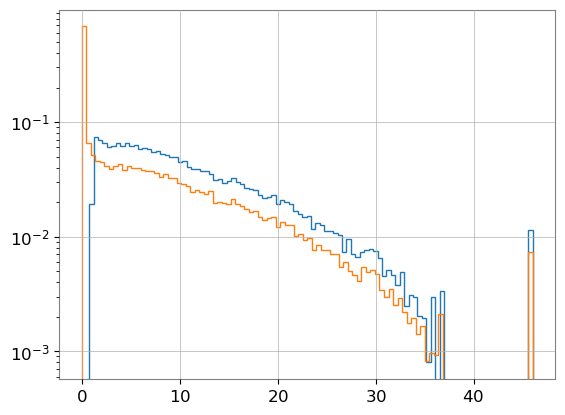

In [208]:
print(len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)])/ len(tmp))
plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.hist(tmp['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')

0.22434446330880967


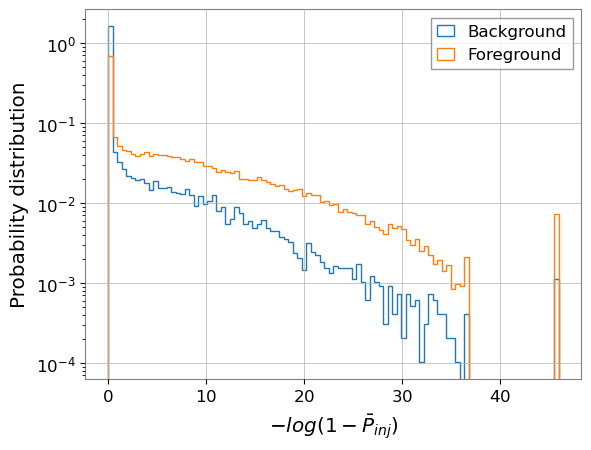

4757 30482


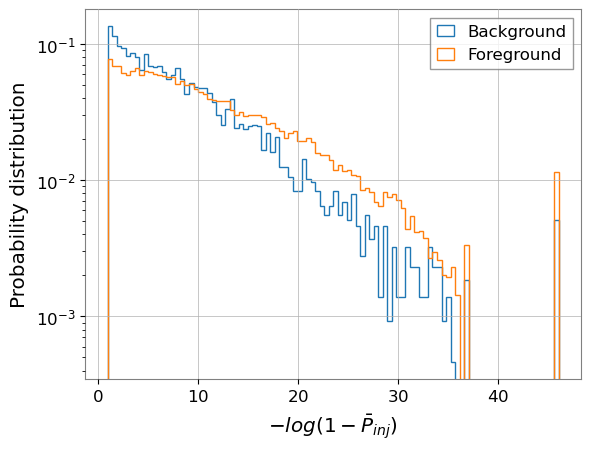

In [259]:
print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)])/ len(bkg))
# plt.hist(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'],
#          bins=100, density=True, histtype='step', label='Background')
# plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], 
#          bins=100, density=True, histtype='step', label='Foreground')

plt.hist(bkg['rank_stat_L1V1'],
          bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp['rank_stat_L1V1'], 
          bins=100, density=True, histtype='step', label='Foreground')

#plt.hist(bkg['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()
plt.show()

plt.hist(bkg[bkg['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp[tmp['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Foreground')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()

print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]), len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]))

In [48]:
!ls ../../runs/zero_lag/

clusters_unknown_h1_reduced.pkl    triggersLV_zero_lag.csv
clusters_unknown_l1_reduced.pkl    triggersLV_zero_lag_eq_match.csv
clusters_unknown_v1_reduced.pkl    unknown_h1.csv
triggersHLV_zero_lag.csv	   unknown_h1_reduced.csv
triggersHLV_zero_lag_eq_match.csv  unknown_l1.csv
triggersHL_zero_lag.csv		   unknown_l1_reduced.csv
triggersHL_zero_lag_eq_match.csv   unknown_v1.csv
triggersHV_zero_lag.csv		   unknown_v1_reduced.csv
triggersHV_zero_lag_eq_match.csv


In [52]:
with open('../../runs/zero_lag/' + f'clusters_unknown_l1_reduced.pkl', 'rb') as f:
    cluster_L1 = pickle.load(f)
with open('../../runs/zero_lag/' + f'clusters_unknown_v1_reduced.pkl', 'rb') as f:
    cluster_V1 = pickle.load(f)

In [82]:
tmp[['Cluster time_L1', 'Cluster time_V1', 'Cluster idx_L1', 'Cluster idx_V1', 
     'rank_stat_L1V1', 'SNR_max_L1', 'SNR_max_V1']].head(10)

,Cluster time_L1,Cluster time_V1,Cluster idx_L1,Cluster idx_V1,rank_stat_L1V1,SNR_max_L1,SNR_max_V1
5272,1241158507.169,1241158507.192,37179,39429,46.052,4.323,4.365
5246,1241146870.299,1241146870.273,36978,39240,46.052,4.320,4.644
13968,1246630220.796,1246630220.804,101035,91119,46.052,4.505,4.350
27106,1258056187.020,1258056187.002,200802,178097,46.052,4.742,4.357
35839,1262006909.480,1262006909.454,273351,245541,46.052,5.054,4.293
9159,1243458588.754,1243458588.779,65928,62405,46.052,4.204,4.208
10048,1243991008.351,1243991008.380,72824,67451,46.052,4.565,4.372
19098,1250711674.392,1250711674.395,140693,123148,46.052,4.115,4.518
39531,1264610119.370,1264610119.385,297653,273977,46.052,4.524,4.292
42170,1266246656.511,1266246656.494,315069,293187,46.052,4.871,5.972


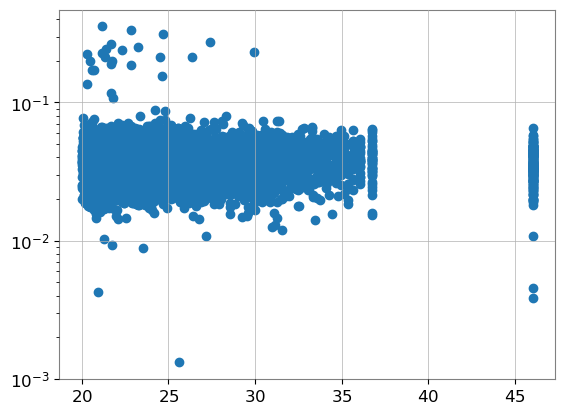

In [210]:
plt.scatter(tmp[tmp['rank_stat_L1V1']> 20]['rank_stat_L1V1'],
            tmp[tmp['rank_stat_L1V1']> 20]['Chisq_max_L1']/tmp[tmp['rank_stat_L1V1']> 20]['SNR_max_L1']**2)
plt.yscale('log')

In [231]:
tmp['rank_stat_L1V1_new'] = tmp['rank_stat_L1V1'].values/((tmp['Chisq_max_L1'].values/tmp['SNR_max_L1'].values**2) +(tmp['Chisq_max_V1'].values/tmp['SNR_max_V1'].values**2))/2
bkg['rank_stat_L1V1_new'] = bkg['rank_stat_L1V1'].values/((bkg['Chisq_max_L1'].values/bkg['SNR_max_L1'].values**2) +(bkg['Chisq_max_V1'].values/bkg['SNR_max_V1'].values**2))/2

In [232]:
tmp = tmp.sort_values(by='rank_stat_L1V1_new', ascending=False)

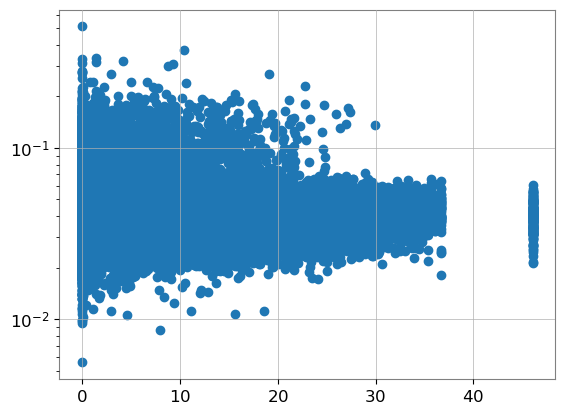

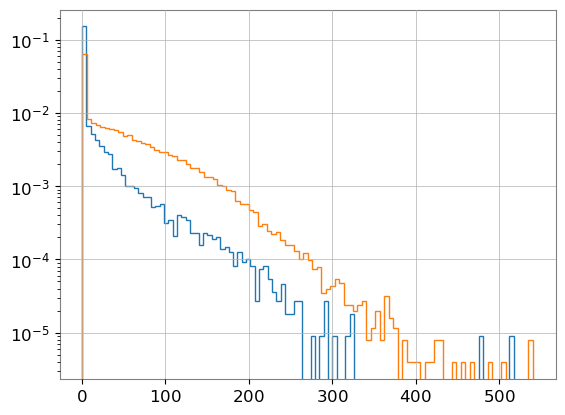

In [233]:
plt.scatter(tmp['rank_stat_L1V1'],
            ((tmp['Chisq_max_L1']/tmp['SNR_max_L1']**2) +(tmp['Chisq_max_V1']/tmp['SNR_max_V1']**2))/2)
plt.yscale('log')
plt.show()

plt.hist(bkg['rank_stat_L1V1_new'],
        bins=100, density=True, histtype='step')
plt.hist(tmp['rank_stat_L1V1_new'],
        bins=100, density=True, histtype='step')
plt.yscale('log')

In [263]:
tmp[['SNR_max_L1', 'Chisq_max_L1', 'SNR_max_V1', 'Chisq_max_V1', 'rank_stat_L1V1', 'rank_stat_L1V1_new']].head(5)

,SNR_max_L1,Chisq_max_L1,SNR_max_V1,Chisq_max_V1,rank_stat_L1V1,rank_stat_L1V1_new
2667,5.577,0.716,5.327,0.555,46.052,540.889
8832,5.072,0.555,6.025,0.772,46.052,537.083
34141,7.252,0.831,4.605,0.434,36.737,506.557
33019,6.292,0.795,7.046,1.330,46.052,491.222
14434,5.691,0.146,4.628,0.960,46.052,466.839


In [267]:
pd.read_csv('timeslides_1132.9y.csv')['slideL'].iloc[0]

3.0

In [268]:
!pwd

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR


In [264]:
cand = tmp.iloc[3]
cand['Cluster time_L1'], cand['SNR_max_L1']

(1260877078.1269271, 6.2920742)

/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


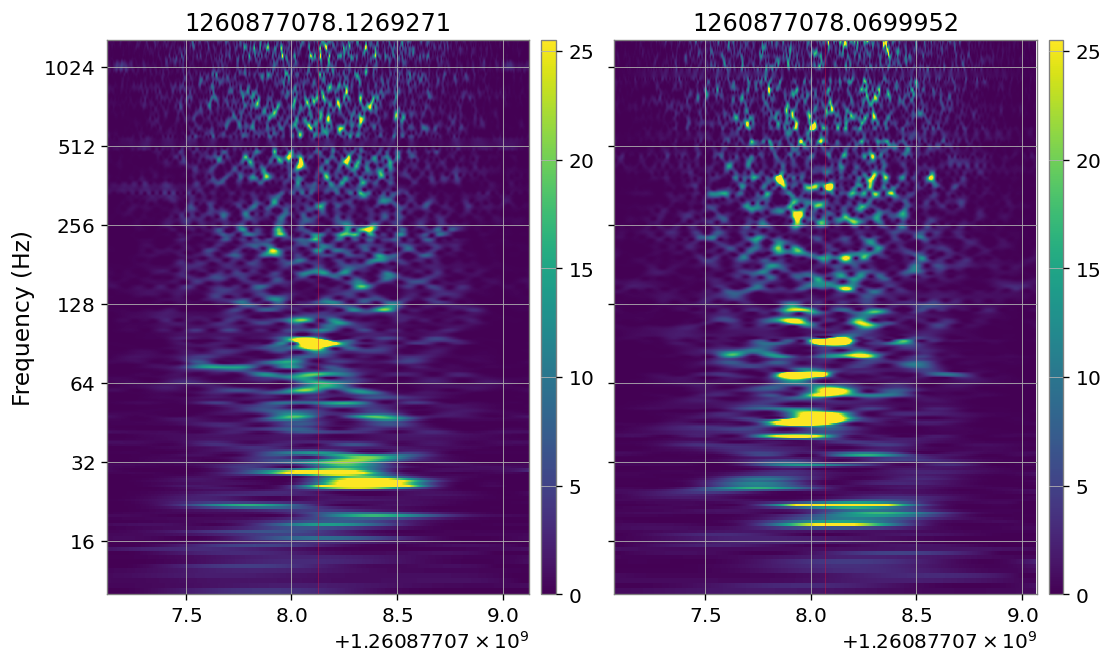

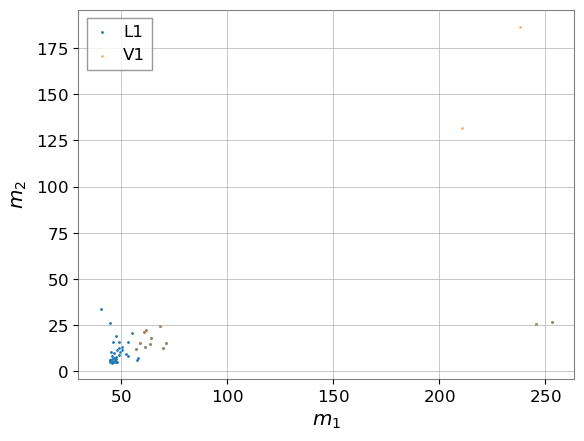

In [265]:
pl.plotSpect2coinc('L1', 'V1', cand['Cluster time_L1'], cand['Cluster time_V1'])
plt.scatter(cluster_L1[cand['Cluster idx_L1']]['Mass_1'], cluster_L1[cand['Cluster idx_L1']]['Mass_2'], s=1, label='L1')
plt.scatter(cluster_V1[cand['Cluster idx_V1']]['Mass_1'], cluster_V1[cand['Cluster idx_V1']]['Mass_2'], s=1, alpha=0.5, label='V1')
plt.xlabel(r'$m_{1}$'), plt.ylabel(r'$m_{2}$')
plt.legend()

In [4]:
def getFARCatalog(foreground, xbkg_obs, ybkg_obs, catalog, ifo, label='FAR_', offset=0.1 ):
    fars = []
    for e in range(len(catalog)):
        t_star = catalog['GPS'].iloc[e]
        cond1 = (foreground['Cluster time_'+ifo[:2]] >= t_star - offset)
        cond2 = (foreground['Cluster time_'+ifo[:2]] <= t_star + offset)
        tmp = foreground[cond1 & cond2]
        if len(tmp) ==  1:
            ranking = tmp['rank_stat_'+ifo].values[0]
            far, _ = Measure.stat2FAR(ranking, xbkg_obs, ybkg_obs) #FIXME
        else:
            far = np.nan
        fars.append(far)
    catalog[label+ifo] = fars
    return catalog

In [5]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

ifo, t_search, FAR = 'H1L1', 0.5, 0.01
for ifo in ifos[:-1]:
    print(ifo)
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    tmp['barPinj'] = Measure.harmonic2coinc(tmp['Pinj_'+ifo[:2]],
                                                            tmp['Pinj_'+ifo[2:]])
    ifo1, ifo2 = ifo[:2], ifo[2:]
        
    foreground = Measure.prob2stat(tmp, ifo[:2]+ifo[2:], col='barPinj')
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    xbkg_obs, ybkg_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
    
    catalog = getFARCatalog(foreground, xbkg_obs, ybkg_obs, catalog, ifo, label='FAR_new_', offset=0.1 )

H1L1
H1V1
L1V1


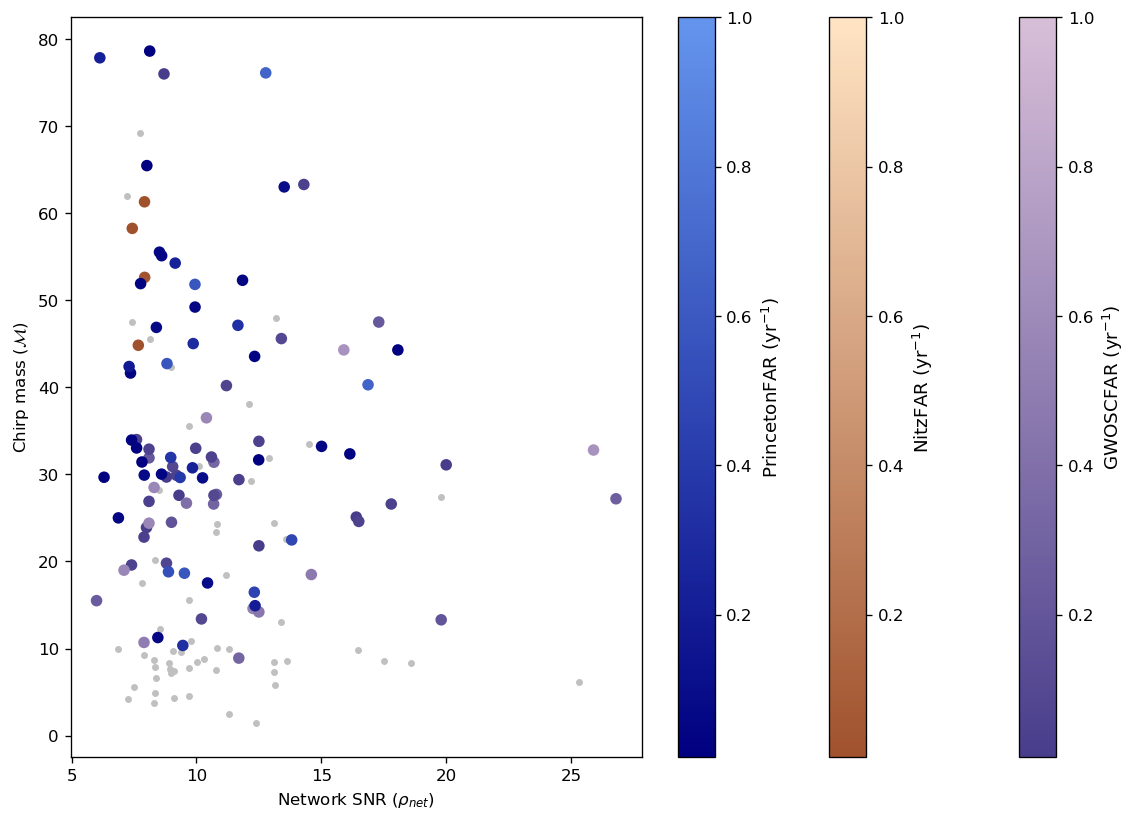

In [7]:
cmap1 = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'thistle'])
cmap2 = LinearSegmentedColormap.from_list(name='test', colors=['sienna', 'bisque'])
cmap3 = LinearSegmentedColormap.from_list(name='test', colors=['navy', 'cornflowerblue'])
fig = plt.figure(figsize=(12, 8), dpi=120)
plt.scatter(catalog['SNR'], catalog['Chirp mass'], c='silver', s=10)
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    tmp = catalog[(catalog['Catalog'] == cat)]
    far = tmp[['FAR_new_H1L1', 'FAR_new_H1V1', 'FAR_new_L1V1']].min(axis=1)
    far = far[far <= 1]
    if cat == 'GWOSC': cmap = cmap1
    if cat == 'Nitz': cmap = cmap2
    if cat  == 'Princeton':cmap = cmap3
    plt.scatter(tmp['SNR'][far.index], tmp['Chirp mass'][far.index], c=far, s=35, cmap=cmap)
    

    cbar = plt.colorbar()
    cbar.set_label(cat + r'FAR (yr$^{-1}$)', fontsize=11)  # Adjust font size of label
    cbar.ax.tick_params(labelsize=10)  # Adjust font size of ticks

    plt.clim(0.01, 1)
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')

In [ ]:
from matplotlib.ticker import StrMethodFormatter
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    df1 = allcatalogs[allcatalogs['Catalog'] == cat]
    df2 = little_dogs[little_dogs['Catalog'] == cat]
    dh1 = df1[df1['inHUll'] == 'p']
    dh2 = df2[df2['inHUll'] == 'p']
    sel_cols = df2[['FAR_H1L1', 'FAR_H1V1', 'FAR_L1V1', 'FAR_H1L1V1']]#[selected_columns].min(axis=1)
    min_values = np.round(sel_cols.min(axis=1),3)
    min_columns = sel_cols.idxmin(axis=1)*10
    
    cmap = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'plum'])
    fig = plt.figure(dpi=120)
    plt.scatter(df1['SNR'], df1['Chirp mass'], c='grey', s=1,alpha=0.8)
    plt.scatter(dh1['SNR'], dh1['Chirp mass'], s=35, color='grey',alpha=0.8, lw=0.5, marker=r'$\odot$', facecolors='none', edgecolors='grey')
  
    plt.scatter(dh2['SNR'], dh2['Chirp mass'],  s=80/20, marker='o', color='white', zorder=10)
    plt.scatter(df2['SNR'], df2['Chirp mass'], c=min_values, s=min_columns.str.len(), cmap=cmap, alpha=0.9)

    cbar = plt.colorbar(label =r'FAR yr$^{-1}$')

    cbar.ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.3f}'))
    plt.clim(0.001, 0.1)
    g1 = plt.scatter([],[], s=1, marker='o', color='silver')
    g3 = plt.scatter([],[], s=8*10, marker='o', color='silver')
    g4 = plt.scatter([],[], s=10*10, marker='o', color='silver')
    
    plt.legend((g1, g3, g4),
           ('Not detected', 'Double coincidence', 'Triple coincidence'),
           scatterpoints=1, fontsize=12,
           ncol=1, loc='upper right')
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')


In [47]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

ifo, t_search = 'H1L1', 0.5
file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
tmp = pd.read_csv(path_zero_lag+file)
tmp['barPinj'] = Measure.harmonic2coinc(tmp['Pinj_'+ifo[:2]],
                                                        tmp['Pinj_'+ifo[2:]])
ifo1, ifo2 = ifo[:2], ifo[2:]
# tmp.rename(columns=lambda col: rename_columns(col, ifo1, ifo1.capitalize()), inplace=True)
# tmp.rename(columns=lambda col: rename_columns(col, ifo2, ifo2.capitalize()), inplace=True)
tmp = Measure.prob2stat(tmp, ifo[:2]+ifo[2:], col='barPinj')
tmp = tmp.sort_values(by='rank_stat_H1L1', ascending=False)


t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
xbkg_obs, ybkg_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.001)
p_star

29.68

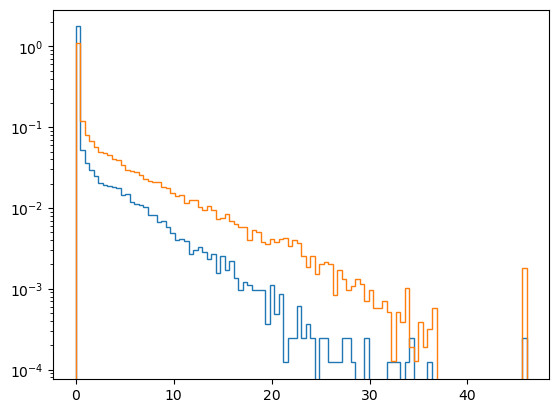

In [14]:
plt.hist(bkg['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.hist(tmp['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.yscale('log')

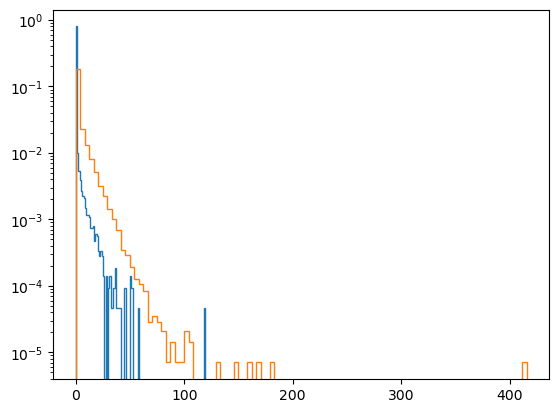

In [9]:
plt.hist(bkg['rank_stat_'+ifo]/(bkg['Chisq_max_H1']*bkg['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.hist(tmp['rank_stat_'+ifo]/(tmp['Chisq_max_H1']*tmp['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.yscale('log')


In [48]:
select_tmp = tmp[tmp['rank_stat_H1L1'] >= p_star]

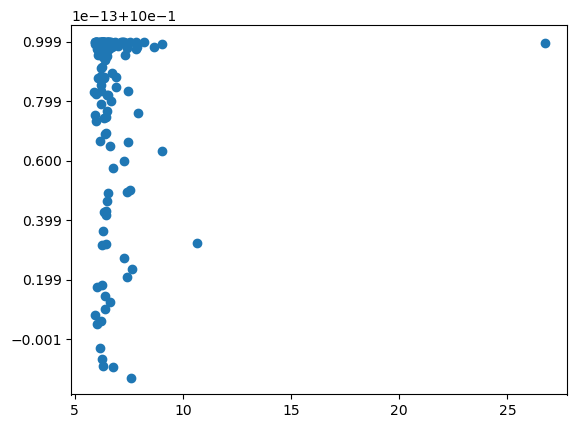

In [49]:
plt.scatter( np.sqrt(select_tmp['SNR_max_H1']**2+ select_tmp['SNR_max_L1']**2), select_tmp['barPinj'])

In [32]:
tmp_ = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/triggersHLV_zero_lag_eq_match.csv')

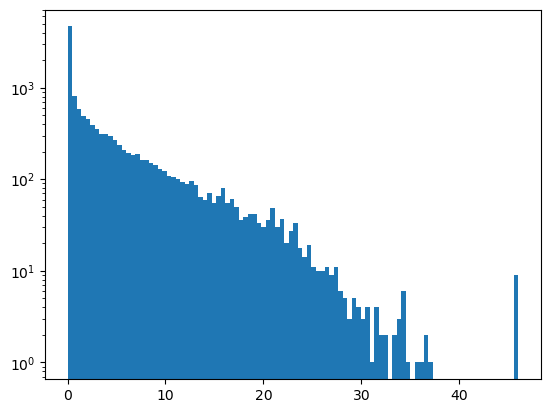

In [38]:
plt.hist(tmp_['rank_stat_H1L1V1'], bins=100)
plt.yscale('log')

In [42]:
tmp_[['Prob_0_L1', 'Prob_1_L1', 'Prob_2_L1', 'Prob_3_L1', 'Prob_4_L1']].head(5)

,Prob_0_L1,Prob_1_L1,Prob_2_L1,Prob_3_L1,Prob_4_L1
0,-0.139,13.599,-35.458,-14.227,-29.425
1,10.471,11.693,-55.404,-19.198,-12.999
2,6.865,7.087,-67.505,24.687,-50.508
3,20.727,-15.627,-72.488,11.142,-87.879
4,33.250,-12.397,-81.347,-21.172,-29.590


In [43]:
tmp_[['Prob_0_H1', 'Prob_1_H1', 'Prob_2_H1', 'Prob_3_H1', 'Prob_4_H1']].head(5)

,Prob_0_H1,Prob_1_H1,Prob_2_H1,Prob_3_H1,Prob_4_H1
0,13.949,-0.839,-82.563,19.481,-228.867
1,32.881,-16.206,-87.853,42.125,-222.688
2,12.904,-36.809,-76.938,13.211,-133.958
3,12.286,-26.999,-98.426,19.015,-190.039
4,10.365,-7.562,-99.630,11.151,-146.874


In [46]:
tmp_[['Pinj_H1', 'Pinj_L1']].head(5)

,Pinj_H1,Pinj_L1
0,0.004,0.000
1,0.000,0.228
2,0.424,0.000
3,0.001,1.000
4,0.313,1.000


In [109]:
t_star = 1251286995
delta = 1
ranking = tmp[(tmp['Cluster time old_H1'] >= t_star - delta) & (tmp['Cluster time old_H1'] <= t_star + delta)]['rank_stat_' + ifo].values[0]

In [34]:
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

dH1, dH1_c = dp.LoadZeroLag('h1', reset=True)

In [42]:
dH1.columns[12:]

# Add suffix to these columns
dH1_ = dH1.rename(columns={col: f"{col}_max" for col in dH1.columns[14:]})


In [44]:
dH1_

,feature,Num triggers,Cluster ID,Cluster time,Cluster idx,Prob_0,Prob_1,Prob_2,Prob_3,Prob_4,...,ifo_max,SNR_max,Chisq_max,Trigger ID_max,Template ID_max,Trigger time_max,Mass_1_max,Mass_2_max,Spin1z_max,Spin2z_max
0,"[4.097591012846227, 0.7772867938523496, 55.764...",10,3.000,1238166107.682,0,10.088,-53.186,-106.908,14.487,-96.853,...,H1,4.238,0.746,1840428.000,4631353.000,1238166107.682,51.283,6.900,-0.856,-0.159
1,"[4.65916040935606, 0.8985506406083005, 50.2712...",14,14.000,1238166243.632,1,1.162,-21.235,-125.210,-3.559,-108.037,...,H1,5.112,0.804,180508.000,393385.000,1238166243.632,52.359,8.497,0.006,-0.354
2,"[4.264480004036605, 1.1007794525725052, 71.454...",19,23.000,1238166274.063,2,6.574,-15.321,-111.685,-4.010,-97.548,...,H1,4.416,1.082,134504.000,8088375.000,1238166274.063,83.682,8.799,0.253,0.287
3,"[4.895605417172906, 1.2619542132147874, 48.293...",42,36.000,1238166293.126,3,1.026,-1.550,-77.382,-5.197,-212.224,...,H1,5.665,1.104,722344.000,2435738.000,1238166293.126,43.938,6.139,0.062,-0.303
4,"[4.023776585303915, 0.8525237545780296, 55.924...",13,39.000,1238166311.110,4,13.990,-36.935,-103.823,11.007,-79.864,...,H1,4.089,0.831,770686.000,4362417.000,1238166311.110,58.205,6.599,-0.846,0.684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354955,"[4.133812916353402, 0.9255935991458847, 42.927...",10,88515.000,1269363336.514,354955,23.625,-4.181,-108.259,4.538,-326.915,...,H1,4.198,0.914,4376860.000,9520704.000,1269363336.514,45.752,10.832,0.508,-0.790
354956,"[5.840365023466128, 0.8154215860470163, 54.660...",11,88522.000,1269363353.471,354956,1.536,-0.897,-116.378,12.389,-208.973,...,H1,5.998,0.768,4220323.000,4672309.000,1269363353.471,58.600,6.277,0.325,-0.584
354957,"[4.338973181349656, 1.336182417930068, 57.6312...",49,88527.000,1269363359.181,354957,13.593,-17.531,-50.147,-7.246,-60.616,...,H1,4.862,1.296,4377352.000,9406247.000,1269363359.181,31.776,27.435,-0.726,-0.660
354958,"[4.566956429402646, 0.9829529681459415, 57.843...",21,88531.000,1269363364.016,354958,17.776,-8.346,-78.830,16.248,-250.279,...,H1,5.112,0.959,4353671.000,9608627.000,1269363364.016,56.914,23.453,0.980,0.828
